In [1]:
import pandas as pd
from river import utils
import os


In [2]:
def save_model(model, path):
    utils.dump(model, path)
    print(f"Model saved to → {path}")
def load_model(path):
    if os.path.exists(path):
        model = utils.load(path)
        print(f"Model loaded from → {path}")
        return model
    return None

In [3]:
df = pd.read_csv( 'cluster-trace-gpu-v2023/csv/openb_pod_list_cpu100.csv')
df

,name,cpu_milli,memory_mib,num_gpu,gpu_milli,gpu_spec,qos,pod_phase,creation_time,deletion_time,scheduled_time
0,openb-pod-0000,12500,57344,0,0,NaN,LS,Running,10644355,10644932,10644358.0
1,openb-pod-0001,12500,57344,0,0,NaN,LS,Running,11556813,11557292,11556817.0
2,openb-pod-0002,32000,49152,0,0,NaN,BE,Running,11412186,11412330,11412189.0
3,openb-pod-0003,16500,51200,0,0,NaN,LS,Running,12524063,12524844,12524064.0
4,openb-pod-0004,8000,30517,0,0,NaN,BE,Running,10741000,10744539,10741002.0
...,...,...,...,...,...,...,...,...,...,...,...
7848,openb-pod-7848,16000,32768,1,1000,NaN,LS,Succeeded,12897160,12900786,12897161.0
7849,openb-pod-7849,11400,77824,1,1000,NaN,LS,Running,12897659,12898203,12897692.0
7850,openb-pod-7850,6000,18432,1,460,NaN,LS,Running,12898342,12900034,12898342.0
7851,openb-pod-7851,3152,5600,1,590,NaN,BE,Failed,12900505,12900526,12900505.0


In [4]:
import math
import numpy as np
import pandas as pd
from collections import deque

from river import (
    ensemble, tree, preprocessing as pp, stream, metrics,
    linear_model, neighbors, optim, utils
)


# Save / Load helpers
def save_model(model, path):
    utils.dump(model, path)
    print(f"Model saved to → {path}")

def load_model(path):
    if os.path.exists(path):
        model = utils.load(path)
        print(f"Model loaded from → {path}")
        return model
    return None


# Data
CSV_PATH = 'cluster-trace-gpu-v2023/csv/openb_pod_list_cpu100.csv'
df = pd.read_csv(CSV_PATH)

# Feature builder
def build_features(df: pd.DataFrame):
    df = df.copy()

    num_cols = ['cpu_milli','memory_mib','num_gpu','gpu_milli',
                'creation_time','deletion_time','scheduled_time']
    for c in num_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')
        else:
            df[c] = 0.0

    y = df['cpu_milli'].fillna(0).astype(float)

    X = pd.DataFrame(index=df.index)
    X['mem_gib'] = (df['memory_mib'].fillna(0) / 1024.0).astype(float)
    X['num_gpu'] = df['num_gpu'].fillna(0).astype(float)
    X['gpu_milli'] = df['gpu_milli'].fillna(0).astype(float)

    ct = df['creation_time'].fillna(0).astype(float)
    dt = df['deletion_time'].fillna(0).astype(float)
    st = df['scheduled_time'].fillna(0).astype(float)
    X['lifetime']   = (dt - ct).clip(lower=0.0)
    X['sched_delay'] = (st - ct).clip(lower=0.0)

    X['has_gpu'] = (X['num_gpu'] > 0).astype(float)

    qos = df.get('qos', '').astype(str).str.upper()
    X['qos_LS'] = (qos == 'LS').astype(float)
    X['qos_BE'] = (qos == 'BE').astype(float)

    phase = df.get('pod_phase', '').astype(str).str.title()
    X['ph_Running']   = (phase == 'Running').astype(float)
    X['ph_Succeeded'] = (phase == 'Succeeded').astype(float)
    X['ph_Failed']    = (phase == 'Failed').astype(float)

    X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0).astype(float)
    features = list(X.columns)
    return X, y, features

X, y, features = build_features(df)

# Models (experts)
def make_bag_ht():
    return ensemble.BaggingRegressor(
        model=tree.HoeffdingTreeRegressor(
            grace_period=100,
            max_depth=20,
            leaf_prediction='mean'
        ),
        n_models=20,
        seed=42
    )

def make_hat():
    return tree.HoeffdingAdaptiveTreeRegressor(
        grace_period=100,
        leaf_prediction='mean'
    )

def make_lin():
    return pp.StandardScaler() | linear_model.PARegressor()

def make_knn():
    engine = neighbors.LazySearch(
        window_size=3000, 
        min_distance_keep=0.0  
    )
    return pp.StandardScaler() | neighbors.KNNRegressor(
        n_neighbors=30,
        engine=engine,
        aggregation_method="mean"  
    )

experts = [make_bag_ht(), make_hat(), make_lin(), make_knn()]

# EWA over experts
ewa = ensemble.EWARegressor(models=experts, loss=optim.losses.Squared(), learning_rate=2e-3)

# Metrics
mae = metrics.MAE()

class OnlineMAPE:
    def __init__(self, eps=1e-8):
        self.eps = eps
        self.n = 0
        self.sum_pe = 0.0
    def update(self, y_true, y_pred):
        y_true = float(y_true); y_pred = float(y_pred)
        pe = abs(y_true - y_pred) / max(self.eps, abs(y_true))
        self.sum_pe += pe
        self.n += 1
    def get(self):
        return (self.sum_pe / max(1, self.n)) * 100.0

class OnlineWAPE:
    def __init__(self, eps=1e-8):
        self.eps = eps
        self.sum_abs_err = 0.0
        self.sum_abs_true = 0.0
    def update(self, y_true, y_pred):
        self.sum_abs_err += abs(float(y_true) - float(y_pred))
        self.sum_abs_true += abs(float(y_true))
    def get(self):
        return 100.0 * self.sum_abs_err / max(self.eps, self.sum_abs_true)

mape, wape = OnlineMAPE(), OnlineWAPE()

# Scaling and loop settings
TARGET_SCALE = 1.0

last_preds = deque(maxlen=40)
WARM_UP = 200
SEEN = 0

NODE_CAPACITY = 8000  
sla_violations = 0
overprov = 0.0
scaling_actions = 0
current_nodes = 1

# Online loop
# Online loop
for x_row, y_true in stream.iter_pandas(X[features], y):
    SEEN += 1

    # Predict
    if SEEN <= WARM_UP:
        preds = [(m.predict_one(x_row) or 0.0) for m in experts]
        y_hat_scaled = float(np.mean(preds)) if preds else 0.0
    else:
        y_hat_scaled = ewa.predict_one(x_row) or 0.0

    # Rescale to original target and clip negatives
    y_hat = max(0.0, y_hat_scaled * TARGET_SCALE)

    # Metrics
    mae.update(y_true, y_hat)
    mape.update(y_true, y_hat)
    wape.update(y_true, y_hat)

    # Autoscaling policy
    needed_nodes = max(1, int(np.ceil(y_hat / NODE_CAPACITY)))
    if needed_nodes * NODE_CAPACITY < float(y_true):
        sla_violations += 1
    overprov += max(0.0, needed_nodes * NODE_CAPACITY - float(y_true))
    if needed_nodes != current_nodes:
        scaling_actions += 1
        current_nodes = needed_nodes

    # Train (scale target for stability)
    y_scaled = float(y_true) / TARGET_SCALE
    for m in experts:
        m.learn_one(x_row, y_scaled)
    if SEEN > WARM_UP:
        ewa.learn_one(x_row, y_scaled)

        # --- enforce minimum weight for all experts ---
        min_w = 0.05
        ewa.weights = np.maximum(ewa.weights, min_w)
        ewa.weights /= ewa.weights.sum()

    last_preds.append((float(y_true), float(y_hat)))

# Report
print("Last 40 predictions (EWA over heterogeneous experts, scaled):")
for i, (yt, yh) in enumerate(last_preds, 1):
    print(f"{i:02d}  Actual={yt:8.2f}  Predicted={yh:8.2f}")

print(f"\nMAE={mae.get():.2f}")
print(f"MAPE={mape.get():.2f}%")
print(f"WAPE={wape.get():.2f}%")

if hasattr(ewa, "weights"):
    print("\nFinal EWA weights:")
    for name, w in zip(["bag_ht","hat","lin","knn"], ewa.weights):
        print(f"  {name:8s}: {w:.3f}")

total_steps = max(1, SEEN)
sla_violation_rate = sla_violations / total_steps
print(f"\nSLA violations: {sla_violations}  (rate = {sla_violation_rate:.3f})")
print(f"Over-provisioned capacity (mCPU): {overprov:.2f}")
print(f"Scaling actions taken: {scaling_actions}") 

Last 40 predictions (EWA over heterogeneous experts, scaled):
01  Actual= 3152.00  Predicted= 3444.71
02  Actual=11400.00  Predicted=11668.89
03  Actual=11400.00  Predicted=15841.52
04  Actual= 8000.00  Predicted= 7729.50
05  Actual=11400.00  Predicted=11599.72
06  Actual= 3152.00  Predicted= 3125.79
07  Actual=11908.00  Predicted=11859.68
08  Actual=11908.00  Predicted=11780.81
09  Actual= 8000.00  Predicted= 5215.86
10  Actual=11908.00  Predicted=11782.47
11  Actual=11908.00  Predicted=11905.70
12  Actual=11908.00  Predicted=11783.29
13  Actual=11400.00  Predicted=11672.30
14  Actual= 8000.00  Predicted= 7743.34
15  Actual=11908.00  Predicted=11810.45
16  Actual=11908.00  Predicted=11810.28
17  Actual=11908.00  Predicted=11806.84
18  Actual=11908.00  Predicted=11784.50
19  Actual=11908.00  Predicted=11784.38
20  Actual= 3152.00  Predicted= 5118.67
21  Actual=11908.00  Predicted=11784.95
22  Actual=11908.00  Predicted=11785.41
23  Actual= 3152.00  Predicted= 3161.93
24  Actual= 3152.0

In [5]:
# -*- coding: utf-8 -*-
# نسخهٔ نهایی: پیش‌بینی آنلاین + تجمیع EWA + سیاست مقیاس‌گذاری (EMA + هیستِریزِس) با ماژول NodePoolManager

import os
import math
import numpy as np
import pandas as pd
from collections import deque

from river import (
    ensemble, tree, preprocessing as pp, stream, metrics,
    linear_model, neighbors, optim, utils
)

# =========================
#  ذخیره/بارگذاری مدل
# =========================
def save_model(model, path):
    utils.dump(model, path)
    print(f"Model saved to → {path}")

def load_model(path):
    if os.path.exists(path):
        model = utils.load(path)
        print(f"Model loaded from → {path}")
        return model
    return None

# =========================
#  مسیر داده
# =========================
CSV_PATH = 'cluster-trace-gpu-v2023/csv/openb_pod_list_cpu100.csv'
df = pd.read_csv(CSV_PATH)

# =========================
#  ساخت ویژگی‌ها
# =========================
def build_features(df: pd.DataFrame):
    df = df.copy()

    num_cols = ['cpu_milli','memory_mib','num_gpu','gpu_milli',
                'creation_time','deletion_time','scheduled_time']
    for c in num_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')
        else:
            df[c] = 0.0

    # هدف
    y = df['cpu_milli'].fillna(0).astype(float)

    # ماتریس ویژگی
    X = pd.DataFrame(index=df.index)
    X['mem_gib'] = (df['memory_mib'].fillna(0) / 1024.0).astype(float)
    X['num_gpu'] = df['num_gpu'].fillna(0).astype(float)
    X['gpu_milli'] = df['gpu_milli'].fillna(0).astype(float)

    ct = df['creation_time'].fillna(0).astype(float)
    dt = df['deletion_time'].fillna(0).astype(float)
    st = df['scheduled_time'].fillna(0).astype(float)
    X['lifetime']    = (dt - ct).clip(lower=0.0)
    X['sched_delay'] = (st - ct).clip(lower=0.0)

    X['has_gpu'] = (X['num_gpu'] > 0).astype(float)

    qos = df.get('qos', '').astype(str).str.upper()
    X['qos_LS'] = (qos == 'LS').astype(float)
    X['qos_BE'] = (qos == 'BE').astype(float)

    phase = df.get('pod_phase', '').astype(str).str.title()
    X['ph_Running']   = (phase == 'Running').astype(float)
    X['ph_Succeeded'] = (phase == 'Succeeded').astype(float)
    X['ph_Failed']    = (phase == 'Failed').astype(float)

    X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0).astype(float)
    features = list(X.columns)
    return X, y, features

X, y, features = build_features(df)

# =========================
#  کارشناسان (مدل‌های پایه)
# =========================
def make_bag_ht():
    return ensemble.BaggingRegressor(
        model=tree.HoeffdingTreeRegressor(
            grace_period=100,
            max_depth=20,
            leaf_prediction='mean'
        ),
        n_models=20,
        seed=42
    )

def make_hat():
    return tree.HoeffdingAdaptiveTreeRegressor(
        grace_period=100,
        leaf_prediction='mean'
    )

def make_lin():
    return pp.StandardScaler() | linear_model.PARegressor()

def make_knn():
    engine = neighbors.LazySearch(window_size=3000, min_distance_keep=0.0)
    return pp.StandardScaler() | neighbors.KNNRegressor(
        n_neighbors=30,
        engine=engine,
        aggregation_method="mean"
    )

experts = [make_bag_ht(), make_hat(), make_lin(), make_knn()]

# =========================
#  تجمیع نمایی وزن‌ها (EWA)
# =========================
ewa = ensemble.EWARegressor(
    models=experts,
    loss=optim.losses.Squared(),
    learning_rate=2e-3
)

# =========================
#  معیارها
# =========================
mae = metrics.MAE()

class OnlineMAPE:
    def __init__(self, eps=1e-8):
        self.eps = eps; self.n = 0; self.sum_pe = 0.0
    def update(self, y_true, y_pred):
        y_true = float(y_true); y_pred = float(y_pred)
        self.sum_pe += abs(y_true - y_pred) / max(self.eps, abs(y_true))
        self.n += 1
    def get(self):
        return 100.0 * self.sum_pe / max(1, self.n)

class OnlineWAPE:
    def __init__(self, eps=1e-8):
        self.eps = eps; self.sae = 0.0; self.sat = 0.0
    def update(self, y_true, y_pred):
        self.sae += abs(float(y_true) - float(y_pred))
        self.sat += abs(float(y_true))
    def get(self):
        return 100.0 * self.sae / max(self.eps, self.sat)

mape, wape = OnlineMAPE(), OnlineWAPE()

# =========================
#  مدیر استخر گره‌ها (EMA + Hysteresis)
# =========================
class NodePoolManager:
    def __init__(self, node_capacity, alpha=0.2, delta_up=0.05, delta_down=0.05, init_nodes=1):
        self.C = node_capacity
        self.alpha = alpha
        self.d_up = delta_up
        self.d_down = delta_down
        self.current_nodes = init_nodes
        self.y_smooth = None
        self.scaling_actions = 0

    def step(self, y_hat):
        # EMA روی پیش‌بینی
        y_hat = max(0.0, float(y_hat))
        if self.y_smooth is None:
            self.y_smooth = y_hat
        else:
            self.y_smooth = self.alpha * y_hat + (1 - self.alpha) * self.y_smooth

        # آستانه‌های هیستریزیس
        up_thr   = (self.current_nodes * self.C) * (1 + self.d_up)
        down_thr = ((self.current_nodes - 1) * self.C) * (1 - self.d_down) if self.current_nodes > 1 else -float("inf")

        # تصمیم
        prev = self.current_nodes
        if self.y_smooth > up_thr:
            self.current_nodes += 1
        elif self.current_nodes > 1 and self.y_smooth < down_thr:
            self.current_nodes -= 1

        if self.current_nodes != prev:
            self.scaling_actions += 1

        return self.current_nodes, self.y_smooth

    def allocated_capacity(self):
        return self.current_nodes * self.C

    # اتصال واقعی به کلاستر (در صورت نیاز)
    def apply_to_cluster(self):
        pass

# =========================
#  تنظیمات و شمارنده‌ها
# =========================
TARGET_SCALE = 1.0
WARM_UP = 200
NODE_CAPACITY = 8000

ALPHA = 0.20        # EMA
DELTA_UP = 0.05     # هیستریزیس (بالا)
DELTA_DOWN = 0.05   # هیستریزیس (پایین)

last_preds = deque(maxlen=40)
SEEN = 0
sla_violations = 0
overprov = 0.0

npm = NodePoolManager(
    node_capacity=NODE_CAPACITY,
    alpha=ALPHA, delta_up=DELTA_UP, delta_down=DELTA_DOWN,
    init_nodes=1
)

# =========================
#  حلقهٔ آنلاین
# =========================
for x_row, y_true in stream.iter_pandas(X[features], y):
    SEEN += 1

    # پیش‌بینی (EWA)
    if SEEN <= WARM_UP:
        preds = [(m.predict_one(x_row) or 0.0) for m in experts]
        y_hat_scaled = float(np.mean(preds)) if preds else 0.0
    else:
        y_hat_scaled = ewa.predict_one(x_row) or 0.0

    y_hat = max(0.0, y_hat_scaled * TARGET_SCALE)

    # معیارهای دقت
    mae.update(y_true, y_hat)
    mape.update(y_true, y_hat)
    wape.update(y_true, y_hat)

    # سیاست مقیاس‌گذاری (EMA + Hysteresis)
    nodes, y_smooth = npm.step(y_hat)
    alloc = npm.allocated_capacity()

    # ارزیابی SLA و اضافه‌ تخصیص
    if alloc < float(y_true):
        sla_violations += 1
    overprov += max(0.0, alloc - float(y_true))

    # یادگیری آنلاین کارشناسان و EWA
    y_scaled = float(y_true) / TARGET_SCALE
    for m in experts:
        m.learn_one(x_row, y_scaled)
    if SEEN > WARM_UP:
        ewa.learn_one(x_row, y_scaled)
        # کف وزن‌ها برای جلوگیری از صفرشدن کامل
        min_w = 0.05
        ewa.weights = np.maximum(ewa.weights, min_w)
        ewa.weights /= ewa.weights.sum()

    last_preds.append((float(y_true), float(y_hat)))

# =========================
#  گزارش نتایج
# =========================
print("Last 40 predictions (EWA over heterogeneous experts, scaled):")
for i, (yt, yh) in enumerate(last_preds, 1):
    print(f"{i:02d}  Actual={yt:8.2f}  Predicted={yh:8.2f}")

print(f"\nMAE={mae.get():.2f}")
print(f"MAPE={mape.get():.2f}%")
print(f"WAPE={wape.get():.2f}%")

if hasattr(ewa, "weights"):
    print("\nFinal EWA weights:")
    for name, w in zip(["bag_ht","hat","lin","knn"], ewa.weights):
        print(f"  {name:8s}: {w:.3f}")

total_steps = max(1, SEEN)
sla_violation_rate = sla_violations / total_steps
print(f"\nSLA violations: {sla_violations}  (rate = {sla_violation_rate:.3f})")
print(f"Over-provisioned capacity (mCPU): {overprov:.2f}")
print(f"Scaling actions taken: {npm.scaling_actions}")


Last 40 predictions (EWA over heterogeneous experts, scaled):
01  Actual= 3152.00  Predicted= 3438.23
02  Actual=11400.00  Predicted=11719.54
03  Actual=11400.00  Predicted=16023.52
04  Actual= 8000.00  Predicted= 7872.35
05  Actual=11400.00  Predicted=11658.51
06  Actual= 3152.00  Predicted= 3113.57
07  Actual=11908.00  Predicted=11885.55
08  Actual=11908.00  Predicted=11807.05
09  Actual= 8000.00  Predicted= 5239.04
10  Actual=11908.00  Predicted=11808.38
11  Actual=11908.00  Predicted=11923.73
12  Actual=11908.00  Predicted=11801.20
13  Actual=11400.00  Predicted=11690.09
14  Actual= 8000.00  Predicted= 7876.15
15  Actual=11908.00  Predicted=11828.45
16  Actual=11908.00  Predicted=11828.16
17  Actual=11908.00  Predicted=11824.61
18  Actual=11908.00  Predicted=11802.15
19  Actual=11908.00  Predicted=11801.91
20  Actual= 3152.00  Predicted= 5106.51
21  Actual=11908.00  Predicted=11799.40
22  Actual=11908.00  Predicted=11802.66
23  Actual= 3152.00  Predicted= 3149.86
24  Actual= 3152.0

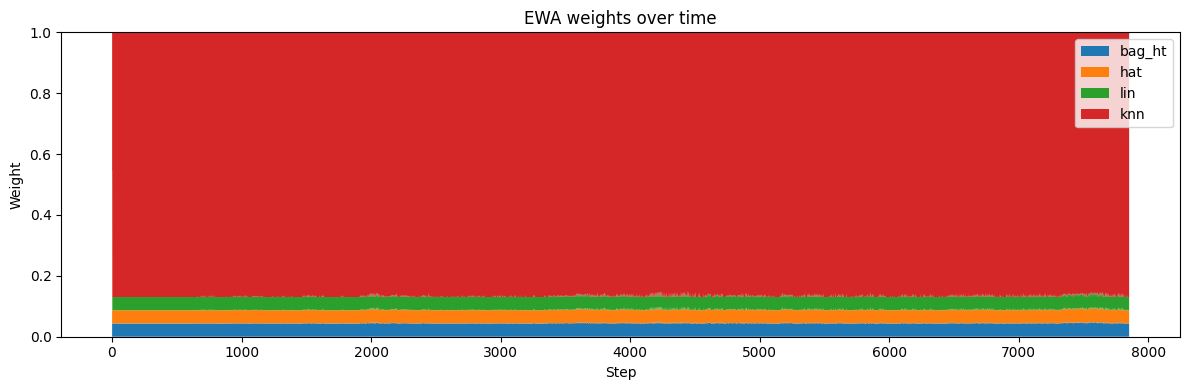

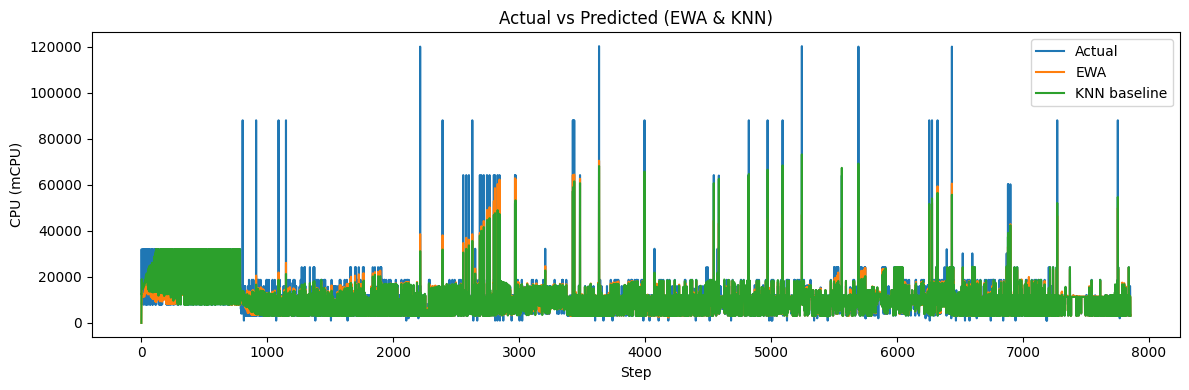

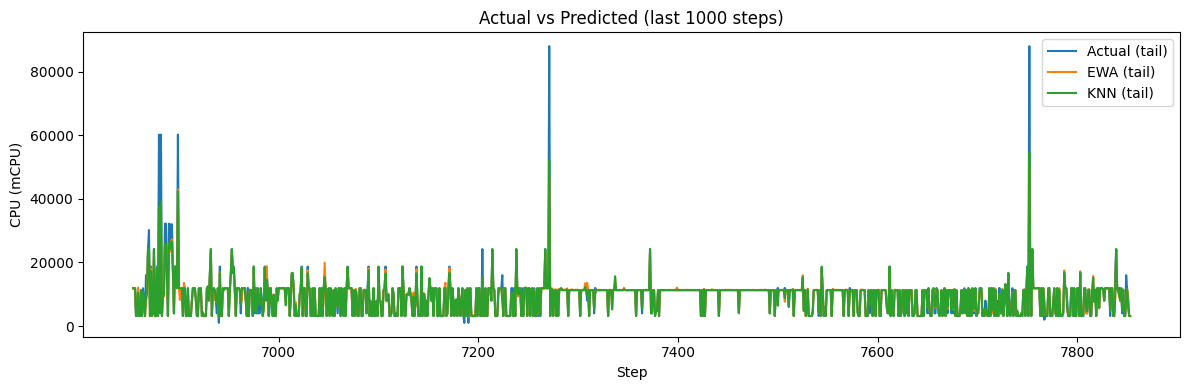

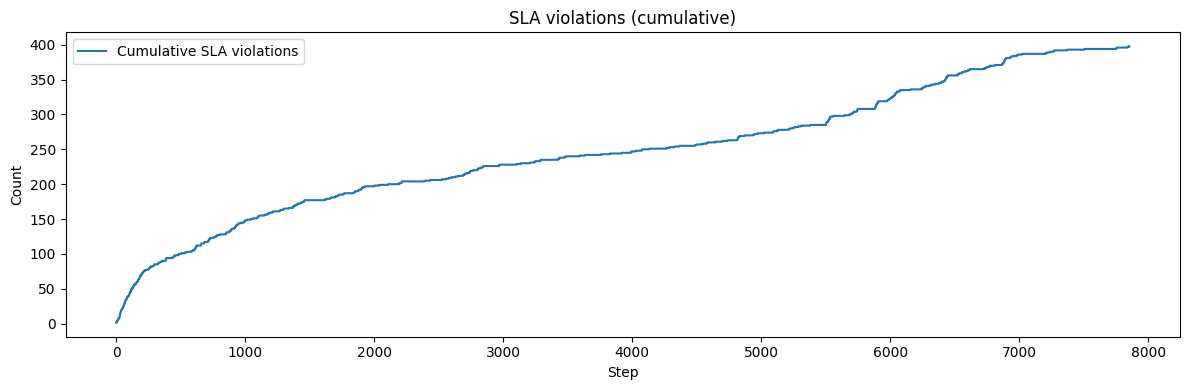

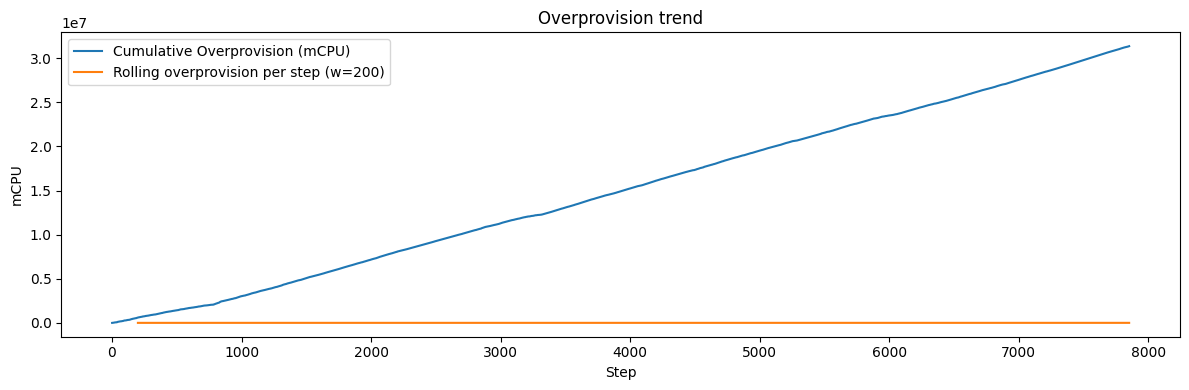

In [6]:
import numpy as np
import pandas as pd
from collections import deque

from river import (
    ensemble, tree, preprocessing as pp, stream, metrics,
    linear_model, neighbors, optim
)

import matplotlib.pyplot as plt

# Data
CSV_PATH = 'cluster-trace-gpu-v2023/csv/openb_pod_list_cpu100.csv'
df = pd.read_csv(CSV_PATH)

def build_features(df: pd.DataFrame):
    df = df.copy()
    num_cols = ['cpu_milli','memory_mib','num_gpu','gpu_milli',
                'creation_time','deletion_time','scheduled_time']
    for c in num_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')
        else:
            df[c] = 0.0

    y = df['cpu_milli'].fillna(0).astype(float)

    X = pd.DataFrame(index=df.index)
    X['mem_gib']   = (df['memory_mib'].fillna(0) / 1024.0).astype(float)
    X['num_gpu']   = df['num_gpu'].fillna(0).astype(float)
    X['gpu_milli'] = df['gpu_milli'].fillna(0).astype(float)

    ct = df['creation_time'].fillna(0).astype(float)
    dt = df['deletion_time'].fillna(0).astype(float)
    st = df['scheduled_time'].fillna(0).astype(float)
    X['lifetime']    = (dt - ct).clip(lower=0.0)
    X['sched_delay'] = (st - ct).clip(lower=0.0)

    X['has_gpu'] = (X['num_gpu'] > 0).astype(float)

    qos = df.get('qos', '').astype(str).str.upper()
    X['qos_LS'] = (qos == 'LS').astype(float)
    X['qos_BE'] = (qos == 'BE').astype(float)

    phase = df.get('pod_phase', '').astype(str).str.title()
    X['ph_Running']   = (phase == 'Running').astype(float)
    X['ph_Succeeded'] = (phase == 'Succeeded').astype(float)
    X['ph_Failed']    = (phase == 'Failed').astype(float)

    X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0).astype(float)
    return X, y, list(X.columns)

X, y, features = build_features(df)

# Models
def make_bag_ht():
    return ensemble.BaggingRegressor(
        model=tree.HoeffdingTreeRegressor(grace_period=100, max_depth=20, leaf_prediction='mean'),
        n_models=20, seed=42
    )

def make_hat():
    return tree.HoeffdingAdaptiveTreeRegressor(grace_period=100, leaf_prediction='mean')

def make_lin():
    return pp.StandardScaler() | linear_model.PARegressor()

def make_knn(window_size=3000, k=30):
    engine = neighbors.LazySearch(window_size=window_size, min_distance_keep=0.0)
    return pp.StandardScaler() | neighbors.KNNRegressor(n_neighbors=k, engine=engine, aggregation_method="mean")

experts = [make_bag_ht(), make_hat(), make_lin(), make_knn()]
ewa = ensemble.EWARegressor(models=experts, loss=optim.losses.Squared(), learning_rate=2e-3)

# KNN baseline
knn_baseline = make_knn(window_size=3000, k=30)

# Settings & logs
WARM_UP = 200
NODE_CAPACITY = 8000
TARGET_SCALE = 1.0

y_true_hist = []
y_hat_ewa_hist = []
y_hat_knn_hist = []

weights_hist = []          
sla_cum_hist = []           
overprov_cum_hist = []       
overprov_step_hist = []       
steps_hist = []

sla_cum = 0
overprov_cum = 0.0
current_nodes = 1
last_preds = deque(maxlen=40)

# Online loop
for t, (x_row, y_true) in enumerate(stream.iter_pandas(X[features], y), start=1):

    # EWA predict 
    if t <= WARM_UP:
        preds = [(m.predict_one(x_row) or 0.0) for m in experts]
        y_hat_ewa = float(np.mean(preds)) if preds else 0.0
    else:
        y_hat_ewa = ewa.predict_one(x_row) or 0.0
    y_hat_ewa = max(0.0, y_hat_ewa * TARGET_SCALE)

    # KNN baseline predict 
    y_hat_knn = knn_baseline.predict_one(x_row) or 0.0
    y_hat_knn = max(0.0, y_hat_knn * TARGET_SCALE)

    # Autoscaling 
    needed_nodes = max(1, int(np.ceil(y_hat_ewa / NODE_CAPACITY)))
    real_needed_nodes = max(1, int(np.ceil(float(y_true) / NODE_CAPACITY)))
    if needed_nodes * NODE_CAPACITY < float(y_true):
        sla_cum += 1
    overprov_step = max(0.0, needed_nodes * NODE_CAPACITY - float(y_true))
    overprov_cum += overprov_step

    # Train 
    y_scaled = float(y_true) / TARGET_SCALE
    for m in experts:
        m.learn_one(x_row, y_scaled)
    ewa.learn_one(x_row, y_scaled)
    knn_baseline.learn_one(x_row, y_scaled)

    # enforce 
    if hasattr(ewa, "weights"):
        min_w = 0.05
        ewa.weights = np.maximum(ewa.weights, min_w)
        ewa.weights /= ewa.weights.sum()

    # log 
    y_true_hist.append(float(y_true))
    y_hat_ewa_hist.append(float(y_hat_ewa))
    y_hat_knn_hist.append(float(y_hat_knn))
    weights_hist.append(ewa.weights.copy() if hasattr(ewa, "weights") else np.zeros(len(experts)))
    sla_cum_hist.append(sla_cum)
    overprov_cum_hist.append(overprov_cum)
    overprov_step_hist.append(overprov_step)
    steps_hist.append(t)

    last_preds.append((float(y_true), float(y_hat_ewa)))

# PLOTS
y_true_hist = np.array(y_true_hist)
y_hat_ewa_hist = np.array(y_hat_ewa_hist)
y_hat_knn_hist = np.array(y_hat_knn_hist)
weights_arr = np.array(weights_hist)
sla_cum_hist = np.array(sla_cum_hist, dtype=float)
overprov_cum_hist = np.array(overprov_cum_hist, dtype=float)
overprov_step_hist = np.array(overprov_step_hist, dtype=float)
steps_hist = np.array(steps_hist)

def rolling_mean(x, w=200):
    if len(x) < w:
        return x.astype(float)
    c = np.cumsum(np.insert(x, 0, 0.0))
    core = (c[w:] - c[:-w]) / float(w)
    # padding 
    pad = np.full(len(x)-len(core), np.nan)
    return np.concatenate([pad, core])

# 1) stacked area
if weights_arr.ndim == 2 and weights_arr.shape[1] == 4:
    labels = ['bag_ht', 'hat', 'lin', 'knn']
    plt.figure(figsize=(12,4))
    plt.stackplot(steps_hist,
                  weights_arr[:,0], weights_arr[:,1], weights_arr[:,2], weights_arr[:,3],
                  labels=labels)
    plt.ylim(0, 1.0)
    plt.title('EWA weights over time')
    plt.xlabel('Step'); plt.ylabel('Weight')
    plt.legend(loc='upper right')
    plt.tight_layout()

# 2) Actual vs Predicted (EWA & KNN)
plt.figure(figsize=(12,4))
plt.plot(steps_hist, y_true_hist, label='Actual')
plt.plot(steps_hist, y_hat_ewa_hist, label='EWA')
plt.plot(steps_hist, y_hat_knn_hist, label='KNN baseline')
plt.title('Actual vs Predicted (EWA & KNN)')
plt.xlabel('Step'); plt.ylabel('CPU (mCPU)')
plt.legend(); plt.tight_layout()

# last 1000 sample
tail = min(1000, len(steps_hist))
plt.figure(figsize=(12,4))
plt.plot(steps_hist[-tail:], y_true_hist[-tail:], label='Actual (tail)')
plt.plot(steps_hist[-tail:], y_hat_ewa_hist[-tail:], label='EWA (tail)')
plt.plot(steps_hist[-tail:], y_hat_knn_hist[-tail:], label='KNN (tail)')
plt.title(f'Actual vs Predicted (last {tail} steps)')
plt.xlabel('Step'); plt.ylabel('CPU (mCPU)')
plt.legend(); plt.tight_layout()

# 3)  SLA violations & Overprovision
plt.figure(figsize=(12,4))
plt.plot(steps_hist, sla_cum_hist, label='Cumulative SLA violations')
plt.title('SLA violations (cumulative)')
plt.xlabel('Step'); plt.ylabel('Count')
plt.legend(); plt.tight_layout()

plt.figure(figsize=(12,4))
plt.plot(steps_hist, overprov_cum_hist, label='Cumulative Overprovision (mCPU)')
rm = rolling_mean(overprov_step_hist, w=200)
plt.plot(steps_hist, rm, label='Rolling overprovision per step (w=200)')
plt.title('Overprovision trend')
plt.xlabel('Step'); plt.ylabel('mCPU')
plt.legend(); plt.tight_layout()

plt.show()


In [7]:
import math
import numpy as np
import pandas as pd
from collections import deque

from river import (
    tree, preprocessing as pp, stream, metrics,
    neighbors, utils
)

# Save / Load helpers
def save_model(model, path):
    utils.dump(model, path)
    print(f"Model saved to → {path}")

def load_model(path):
    try:
        model = utils.load(path)
        print(f"Model loaded from → {path}")
        return model
    except Exception:
        return None


# Data
CSV_PATH = 'cluster-trace-gpu-v2023/csv/openb_pod_list_cpu100.csv'
df = pd.read_csv(CSV_PATH)

# Feature builder
def build_features(df: pd.DataFrame):
    df = df.copy()

    num_cols = ['cpu_milli','memory_mib','num_gpu','gpu_milli',
                'creation_time','deletion_time','scheduled_time']
    for c in num_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')
        else:
            df[c] = 0.0

    y = df['cpu_milli'].fillna(0).astype(float)

    X = pd.DataFrame(index=df.index)
    X['mem_gib']   = (df['memory_mib'].fillna(0) / 1024.0).astype(float)
    X['num_gpu']   = df['num_gpu'].fillna(0).astype(float)
    X['gpu_milli'] = df['gpu_milli'].fillna(0).astype(float)

    ct = df['creation_time'].fillna(0).astype(float)
    dt = df['deletion_time'].fillna(0).astype(float)
    st = df['scheduled_time'].fillna(0).astype(float)
    X['lifetime']    = (dt - ct).clip(lower=0.0)
    X['sched_delay'] = (st - ct).clip(lower=0.0)

    X['has_gpu'] = (X['num_gpu'] > 0).astype(float)

    qos_series = df['qos'].astype(str).str.upper() if 'qos' in df.columns else pd.Series(['']*len(df), index=df.index)
    X['qos_LS'] = (qos_series == 'LS').astype(float)
    X['qos_BE'] = (qos_series == 'BE').astype(float)

    phase_series = df['pod_phase'].astype(str).str.title() if 'pod_phase' in df.columns else pd.Series(['']*len(df), index=df.index)
    X['ph_Running']   = (phase_series == 'Running').astype(float)
    X['ph_Succeeded'] = (phase_series == 'Succeeded').astype(float)
    X['ph_Failed']    = (phase_series == 'Failed').astype(float)

    X['log_lifetime']    = np.log1p(X['lifetime'])
    X['log_sched_delay'] = np.log1p(X['sched_delay'])

    X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0).astype(float)
    features = list(X.columns)
    return X, y, features

X, y, features = build_features(df)
# KNN-only model
def make_knn(window_size=1500, n_neighbors=30):
    engine = neighbors.LazySearch(
        window_size=window_size,
        min_distance_keep=0.0
    )
    return pp.StandardScaler() | neighbors.KNNRegressor(
        n_neighbors=n_neighbors,
        engine=engine,
        aggregation_method="mean"
    )

knn = make_knn(window_size=1500, n_neighbors=30)

# Metrics
mae = metrics.MAE()

class OnlineMAPE:
    def __init__(self, eps=1e-8):
        self.eps = eps; self.n = 0; self.sum_pe = 0.0
    def update(self, y_true, y_pred):
        y_true = float(y_true); y_pred = float(y_pred)
        pe = abs(y_true - y_pred) / max(self.eps, abs(y_true))
        self.sum_pe += pe; self.n += 1
    def get(self): return (self.sum_pe / max(1, self.n)) * 100.0

class OnlineWAPE:
    def __init__(self, eps=1e-8):
        self.eps = eps; self.sum_abs_err = 0.0; self.sum_abs_true = 0.0
    def update(self, y_true, y_pred):
        self.sum_abs_err += abs(float(y_true) - float(y_pred))
        self.sum_abs_true += abs(abs(float(y_true)))
    def get(self):
        return 100.0 * self.sum_abs_err / max(self.eps, self.sum_abs_true)

mape, wape = OnlineMAPE(), OnlineWAPE()

# Autoscaling settings
TARGET_SCALE = 1.0
NODE_CAPACITY = 8000

last_preds = deque(maxlen=40)
SEEN = 0

sla_violations = 0
overprov = 0.0
scaling_actions = 0
current_nodes = 1

USE_EMA = True
EMA_ALPHA = 0.2
ema_pred = None

# Online loop (KNN only)
for x_row, y_true in stream.iter_pandas(X[features], y):
    SEEN += 1

    # Predict (KNN)
    y_hat_raw = knn.predict_one(x_row) or 0.0
    y_hat_raw = max(0.0, y_hat_raw * TARGET_SCALE)

    # EMA smoothing 
    if USE_EMA:
        ema_pred = y_hat_raw if ema_pred is None else (EMA_ALPHA*y_hat_raw + (1-EMA_ALPHA)*ema_pred)
        y_hat = ema_pred
    else:
        y_hat = y_hat_raw

    # Metrics
    mae.update(y_true, y_hat)
    mape.update(y_true, y_hat)
    wape.update(y_true, y_hat)

    # Autoscaling 
    needed_nodes = max(1, int(np.ceil(y_hat / NODE_CAPACITY)))
    if needed_nodes * NODE_CAPACITY < float(y_true):
        sla_violations += 1
    overprov += max(0.0, needed_nodes * NODE_CAPACITY - float(y_true))
    if needed_nodes != current_nodes:
        scaling_actions += 1
        current_nodes = needed_nodes

    # Online learning
    y_scaled = float(y_true) / TARGET_SCALE
    knn.learn_one(x_row, y_scaled)

    last_preds.append((float(y_true), float(y_hat)))

# Report
print("Last 40 predictions (KNN only):")
for i, (yt, yh) in enumerate(last_preds, 1):
    print(f"{i:02d}  Actual={yt:8.2f}  Predicted={yh:8.2f}")

print(f"\nMAE={mae.get():.2f}")
print(f"MAPE={mape.get():.2f}%")
print(f"WAPE={wape.get():.2f}%")

total_steps = max(1, SEEN)
sla_violation_rate = sla_violations / total_steps
print(f"\nSLA violations: {sla_violations}  (rate = {sla_violation_rate:.3f})")
print(f"Over-provisioned capacity (total mCPU): {overprov:.2f}")
print(f"Over-provisioned capacity (avg per step mCPU): {overprov/total_steps:.2f}")
print(f"Scaling actions taken: {scaling_actions}")


Last 40 predictions (KNN only):
01  Actual= 3152.00  Predicted= 7416.18
02  Actual=11400.00  Predicted= 8611.88
03  Actual=11400.00  Predicted= 9665.67
04  Actual= 8000.00  Predicted= 8739.21
05  Actual=11400.00  Predicted= 9961.95
06  Actual= 3152.00  Predicted= 8599.96
07  Actual=11908.00  Predicted= 9261.57
08  Actual=11908.00  Predicted= 9790.86
09  Actual= 8000.00  Predicted= 8859.35
10  Actual=11908.00  Predicted= 9469.08
11  Actual=11908.00  Predicted= 9956.86
12  Actual=11908.00  Predicted=10347.09
13  Actual=11400.00  Predicted=11085.59
14  Actual= 8000.00  Predicted=10222.21
15  Actual=11908.00  Predicted=10559.37
16  Actual=11908.00  Predicted=10829.09
17  Actual=11908.00  Predicted=11044.87
18  Actual=11908.00  Predicted=11217.50
19  Actual=11908.00  Predicted=11355.60
20  Actual= 3152.00  Predicted=10451.12
21  Actual=11908.00  Predicted=10742.50
22  Actual=11908.00  Predicted=10975.60
23  Actual= 3152.00  Predicted= 9410.88
24  Actual= 3152.00  Predicted= 8159.10
25  Actu

In [10]:
import os
import numpy as np
import pandas as pd
from collections import deque

from statsmodels.tsa.api import ExponentialSmoothing, SARIMAX


CSV_PATH = 'cluster-trace-gpu-v2023/csv/openb_pod_list_cpu100.csv'

NODE_CAPACITY = 8000  

INIT_WINDOW = 500     
REFIT_EVERY = 250     
CLIP_NEGATIVE = True    

class MAE:
    def __init__(self): self.err = 0.0; self.n = 0
    def update(self, y, yhat):
        self.err += abs(float(y) - float(yhat)); self.n += 1
    def get(self): return self.err / max(1, self.n)

class OnlineMAPE:
    def __init__(self, eps=1e-8): self.eps=eps; self.n=0; self.sum_pe=0.0
    def update(self, y, yhat):
        y = float(y); yhat = float(yhat)
        pe = abs(y - yhat) / max(self.eps, abs(y))
        self.sum_pe += pe; self.n += 1
    def get(self): return 100.0 * self.sum_pe / max(1, self.n)

class OnlineWAPE:
    def __init__(self, eps=1e-8): self.eps=eps; self.sae=0.0; self.sat=0.0
    def update(self, y, yhat):
        self.sae += abs(float(y)-float(yhat))
        self.sat += abs(float(y))
    def get(self): return 100.0 * self.sae / max(self.eps, self.sat)

def autoscale_metrics(y_true_seq, y_hat_seq, node_capacity=NODE_CAPACITY):
    """
    Compute SLA violations, Over-Provision (raw and normalized), Scaling actions.
    """
    sla_violations = 0
    overprov_raw = 0.0
    scaling_actions = 0
    current_nodes = 1

    for y_true, y_hat in zip(y_true_seq, y_hat_seq):
        needed_nodes = max(1, int(np.ceil(float(y_hat) / node_capacity)))
        if needed_nodes * node_capacity < float(y_true):
            sla_violations += 1
        overprov_raw += max(0.0, needed_nodes * node_capacity - float(y_true))
        if needed_nodes != current_nodes:
            scaling_actions += 1
            current_nodes = needed_nodes

    total = len(y_true_seq)
    sla_rate = sla_violations / max(1, total)
    denom = sum(map(float, y_true_seq)) + 1e-8
    overprov_rate = overprov_raw / denom

    return dict(
        sla_violations=sla_violations,
        sla_rate=sla_rate,
        overprov_raw=overprov_raw,
        overprov_rate=overprov_rate,
        scaling_actions=scaling_actions
    )

def load_ordered_series(csv_path=CSV_PATH):
    df = pd.read_csv(csv_path)
    if 'creation_time' not in df.columns:
        raise ValueError("creation_time column is required for proper time ordering.")

    df['creation_time'] = pd.to_numeric(df['creation_time'], errors='coerce').fillna(0).astype(float)
    df['cpu_milli'] = pd.to_numeric(df['cpu_milli'], errors='coerce').fillna(0).astype(float)

    df = df.sort_values('creation_time').reset_index(drop=True)
    y = df['cpu_milli'].astype(float).values 
    return y, df
def baseline_naive_last(y):
    preds = []
    last = y[0]
    for t in range(len(y)):
        if t < 1:
            preds.append(y[0])  
        else:
            preds.append(last)
        last = y[t]
    return np.array(preds, dtype=float)

def baseline_moving_average(y, window=20):
    preds = []
    csum = 0.0
    buf = []
    for t in range(len(y)):
        if t < 1:
            preds.append(y[0])
        else:
            w = min(window, len(buf))
            mean = np.mean(buf[-w:]) if w > 0 else y[t-1]
            preds.append(mean)
        buf.append(y[t])
    return np.array(preds, dtype=float)

def baseline_holt_winters(y, trend='add', seasonal=None, seasonal_periods=None):

    n = len(y)
    preds = np.zeros(n, dtype=float)
    preds[:INIT_WINDOW] = baseline_naive_last(y)[:INIT_WINDOW]

    last_refit = INIT_WINDOW
    model = None
    fit = None

    for t in range(INIT_WINDOW, n):
        if (t - last_refit) >= REFIT_EVERY or fit is None:
            model = ExponentialSmoothing(
                y[:t],
                trend=trend,
                seasonal=seasonal,
                seasonal_periods=seasonal_periods,
                initialization_method="estimated"
            )
            fit = model.fit(optimized=True, use_brute=False)
            last_refit = t
        preds[t] = float(fit.forecast(1)[0])
    return preds

def baseline_sarima(y, order=(1,1,1), seasonal_order=(0,0,0,0)):
    n = len(y)
    preds = np.zeros(n, dtype=float)
    preds[:INIT_WINDOW] = baseline_naive_last(y)[:INIT_WINDOW]

    last_refit = INIT_WINDOW
    fit = None

    for t in range(INIT_WINDOW, n):
        if (t - last_refit) >= REFIT_EVERY or fit is None:
            try:
                model = SARIMAX(
                    y[:t],
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )
                fit = model.fit(disp=False)
                last_refit = t
            except Exception as e:
                fit = None
        if fit is not None:
            try:
                preds[t] = float(fit.forecast(1)[0])
            except Exception:
                preds[t] = y[t-1]
        else:
            preds[t] = y[t-1]
    return preds

def evaluate_forecasts(y_true, y_hat, name="MODEL"):
    if CLIP_NEGATIVE:
        y_hat = np.maximum(0.0, y_hat)

    last_preds = deque(maxlen=40)
    mae = MAE(); mape = OnlineMAPE(); wape = OnlineWAPE()

    for yt, yh in zip(y_true, y_hat):
        mae.update(yt, yh); mape.update(yt, yh); wape.update(yt, yh)
        last_preds.append((float(yt), float(yh)))

    auto = autoscale_metrics(y_true, y_hat, node_capacity=NODE_CAPACITY)

    print(f"\n=== {name} ===")
    print("Last 40 predictions:")
    for i, (yt, yh) in enumerate(last_preds, 1):
        print(f"{i:02d}  Actual={yt:8.2f}  Predicted={yh:8.2f}")

    print(f"\nMAE={mae.get():.2f}")
    print(f"MAPE={mape.get():.2f}%")
    print(f"WAPE={wape.get():.2f}%")
    print(f"SLA violations: {auto['sla_violations']}  (rate={auto['sla_rate']:.3f})")
    print(f"Over-provision (raw mCPU): {auto['overprov_raw']:.2f}")
    print(f"Over-provision RATE: {100.0*auto['overprov_rate']:.2f}%")
    print(f"Scaling actions taken: {auto['scaling_actions']}")


if __name__ == "__main__":
    y, df = load_ordered_series(CSV_PATH)

    yhat_naive = baseline_naive_last(y)
    evaluate_forecasts(y, yhat_naive, name="Naive-LAST")

    yhat_ma = baseline_moving_average(y, window=30)
    evaluate_forecasts(y, yhat_ma, name="MovingAverage-30")

    yhat_hw = baseline_holt_winters(y, trend="add", seasonal=None, seasonal_periods=None)
    evaluate_forecasts(y, yhat_hw, name="HoltWinters(trend=add)")
    yhat_arima = baseline_sarima(y, order=(1,1,1), seasonal_order=(0,0,0,0))
    evaluate_forecasts(y, yhat_arima, name="SARIMA(1,1,1)")



=== Naive-LAST ===
Last 40 predictions:
01  Actual=11400.00  Predicted= 3152.00
02  Actual=11400.00  Predicted=11400.00
03  Actual=32000.00  Predicted=11400.00
04  Actual= 8000.00  Predicted=32000.00
05  Actual=11400.00  Predicted= 8000.00
06  Actual= 3152.00  Predicted=11400.00
07  Actual=11908.00  Predicted= 3152.00
08  Actual=11908.00  Predicted=11908.00
09  Actual= 8000.00  Predicted=11908.00
10  Actual=11908.00  Predicted= 8000.00
11  Actual=11908.00  Predicted=11908.00
12  Actual=11908.00  Predicted=11908.00
13  Actual=11400.00  Predicted=11908.00
14  Actual= 8000.00  Predicted=11400.00
15  Actual=11908.00  Predicted= 8000.00
16  Actual=11908.00  Predicted=11908.00
17  Actual=11908.00  Predicted=11908.00
18  Actual=11908.00  Predicted=11908.00
19  Actual=11908.00  Predicted=11908.00
20  Actual= 3152.00  Predicted=11908.00
21  Actual=11908.00  Predicted= 3152.00
22  Actual=11908.00  Predicted=11908.00
23  Actual= 3152.00  Predicted=11908.00
24  Actual= 3152.00  Predicted= 3152.00

In [29]:
pip install scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 2.7 MB/s  0:00:03 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


Last 40 predictions (EWA):
01  Actual=11400.00  Predicted=13137.60
02  Actual=11400.00  Predicted=16377.43
03  Actual=32000.00  Predicted=29341.82
04  Actual= 8000.00  Predicted= 5460.41
05  Actual=11400.00  Predicted=14404.20
06  Actual= 3152.00  Predicted= 3148.72
07  Actual=11908.00  Predicted=11877.91
08  Actual=11908.00  Predicted=11879.41
09  Actual= 8000.00  Predicted= 5390.23
10  Actual=11908.00  Predicted=11881.54
11  Actual=11908.00  Predicted=11891.55
12  Actual=11908.00  Predicted=11880.86
13  Actual=11400.00  Predicted=13542.05
14  Actual= 8000.00  Predicted= 6380.32
15  Actual=11908.00  Predicted=11879.87
16  Actual=11908.00  Predicted=11876.88
17  Actual=11908.00  Predicted=11876.79
18  Actual=11908.00  Predicted=11881.52
19  Actual=11908.00  Predicted=11881.92
20  Actual= 3152.00  Predicted= 7065.93
21  Actual=11908.00  Predicted=11883.06
22  Actual=11908.00  Predicted=11882.87
23  Actual= 3152.00  Predicted= 3150.24
24  Actual= 3152.00  Predicted= 3145.86
25  Actual=16

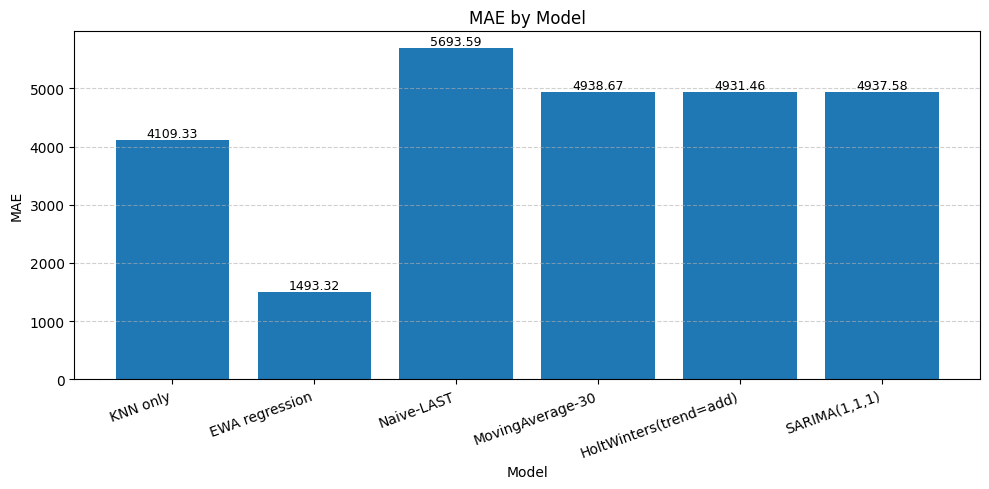

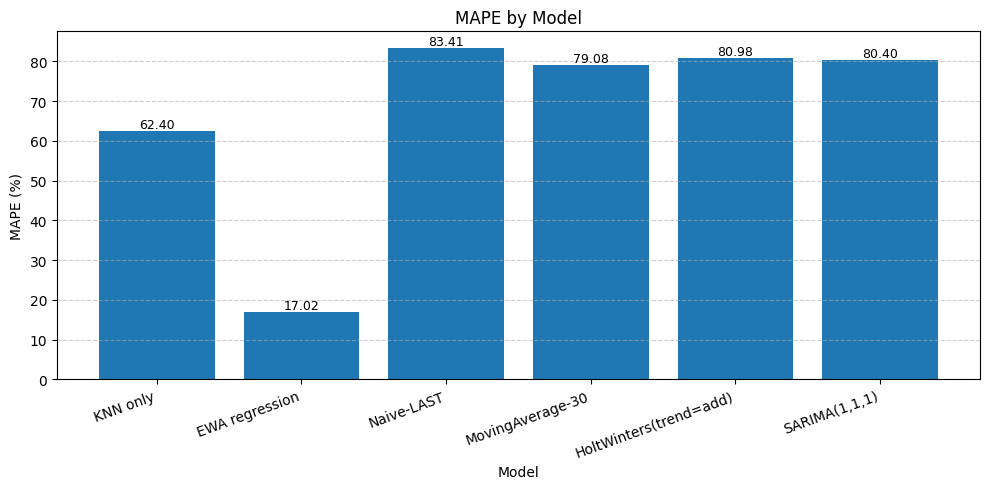

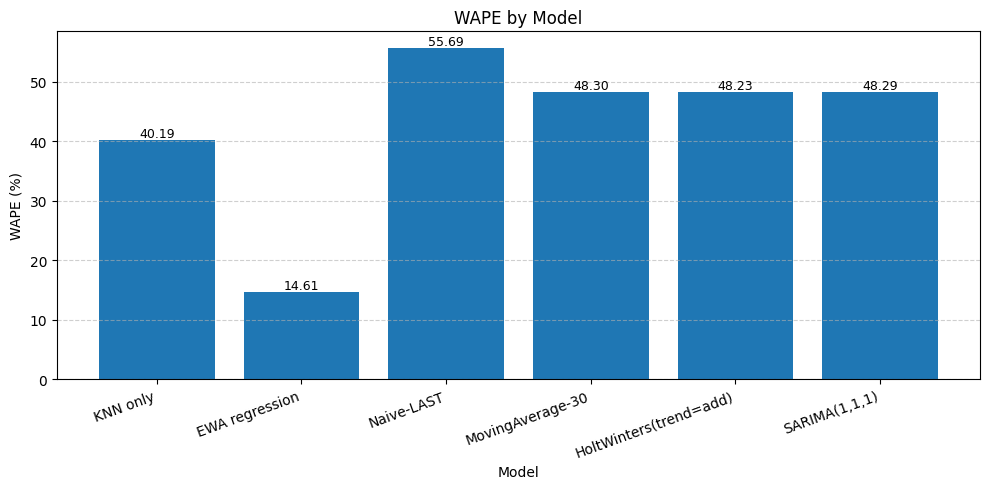

In [32]:
# -*- coding: utf-8 -*-
# نسخهٔ یکپارچه: Online EWA + KNN-only (river) و Baselines سری‌زمانی + نمودارهای MAE/MAPE/WAPE

import os
import math
import numpy as np
import pandas as pd
from collections import deque
import matplotlib.pyplot as plt

from river import (
    ensemble, tree, preprocessing, stream, metrics,
    linear_model, neighbors, optim, utils
)
from statsmodels.tsa.api import ExponentialSmoothing, SARIMAX

# =========================
#  مسیر داده
# =========================
CSV_PATH = 'cluster-trace-gpu-v2023/csv/openb_pod_list_cpu100.csv'
df = pd.read_csv(CSV_PATH)

# مهم: ترتیب زمانی برای یادگیری/پیش‌بینی آنلاین
if 'creation_time' in df.columns:
    df['creation_time'] = pd.to_numeric(df['creation_time'], errors='coerce')
    df = df.sort_values('creation_time').reset_index(drop=True)

# =========================
#  ساخت ویژگی‌ها (برای مدل‌های river)
# =========================
def build_features(df: pd.DataFrame):
    df = df.copy()

    num_cols = ['cpu_milli','memory_mib','num_gpu','gpu_milli',
                'creation_time','deletion_time','scheduled_time']
    for c in num_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')
        else:
            df[c] = 0.0

    y = df['cpu_milli'].fillna(0).astype(float)

    X = pd.DataFrame(index=df.index)
    X['mem_gib']   = (df['memory_mib'].fillna(0) / 1024.0).astype(float)
    X['num_gpu']   = df['num_gpu'].fillna(0).astype(float)
    X['gpu_milli'] = df['gpu_milli'].fillna(0).astype(float)

    ct = df['creation_time'].fillna(0).astype(float)
    dt = df['deletion_time'].fillna(0).astype(float)
    st = df['scheduled_time'].fillna(0).astype(float)
    X['lifetime']    = (dt - ct).clip(lower=0.0)
    X['sched_delay'] = (st - ct).clip(lower=0.0)

    X['has_gpu'] = (X['num_gpu'] > 0).astype(float)

    qos_series = df['qos'].astype(str).str.upper() if 'qos' in df.columns else pd.Series(['']*len(df), index=df.index)
    X['qos_LS'] = (qos_series == 'LS').astype(float)
    X['qos_BE'] = (qos_series == 'BE').astype(float)

    phase_series = df['pod_phase'].astype(str).str.title() if 'pod_phase' in df.columns else pd.Series(['']*len(df), index=df.index)
    X['ph_Running']   = (phase_series == 'Running').astype(float)
    X['ph_Succeeded'] = (phase_series == 'Succeeded').astype(float)
    X['ph_Failed']    = (phase_series == 'Failed').astype(float)

    # اختیاری: ویژگی‌های لگاریتمی
    X['log_lifetime']    = np.log1p(X['lifetime'])
    X['log_sched_delay'] = np.log1p(X['sched_delay'])

    X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0).astype(float)
    features = list(X.columns)
    return X, y, features

X, y, features = build_features(df)

# =========================
#  متریک‌ها
# =========================
class MAE:
    def __init__(self): self.err = 0.0; self.n = 0
    def update(self, y, yhat):
        self.err += abs(float(y) - float(yhat)); self.n += 1
    def get(self): return self.err / max(1, self.n)

class OnlineMAPE:
    def __init__(self, eps=1e-8): self.eps=eps; self.n=0; self.sum_pe=0.0
    def update(self, y, yhat):
        y = float(y); yhat = float(yhat)
        self.sum_pe += abs(y - yhat) / max(self.eps, abs(y))
        self.n += 1
    def get(self): return 100.0 * self.sum_pe / max(1, self.n)

class OnlineWAPE:
    def __init__(self, eps=1e-8): self.eps=eps; self.sae=0.0; self.sat=0.0
    def update(self, y, yhat):
        self.sae += abs(float(y)-float(yhat))
        self.sat += abs(float(y))
    def get(self): return 100.0 * self.sae / max(self.eps, self.sat)

# =========================
#  مدل‌های river (کارشناسان + EWA + KNN-only)
# =========================
def make_bag_ht():
    return ensemble.BaggingRegressor(
        model=tree.HoeffdingTreeRegressor(
            grace_period=100,
            max_depth=20,
            leaf_prediction='mean'
        ),
        n_models=20,
        seed=42
    )

def make_hat():
    return tree.HoeffdingAdaptiveTreeRegressor(
        grace_period=100,
        leaf_prediction='mean'
    )

def make_lin():
    return preprocessing.StandardScaler() | linear_model.PARegressor()

def make_knn(window_size=3000, n_neighbors=30):
    engine = neighbors.LazySearch(window_size=window_size, min_distance_keep=0.0)
    return preprocessing.StandardScaler() | neighbors.KNNRegressor(
        n_neighbors=n_neighbors,
        engine=engine,
        aggregation_method="mean"
    )

experts = [make_bag_ht(), make_hat(), make_lin(), make_knn()]
ewa = ensemble.EWARegressor(models=experts, loss=optim.losses.Squared(), learning_rate=2e-3)

# «KNN only» مستقل (همپارامتر با نسخهٔ مستقل قبلی)
knn_only = preprocessing.StandardScaler() | neighbors.KNNRegressor(
    n_neighbors=30,
    engine=neighbors.LazySearch(window_size=1500, min_distance_keep=0.0),
    aggregation_method="mean"
)

# =========================
#  تنظیمات
# =========================
TARGET_SCALE = 1.0
WARM_UP = 200

# EMA برای KNN only (مثل نسخهٔ مستقل)
USE_EMA_KNN = True
EMA_ALPHA_KNN = 0.20
ema_knn = None

# برای گزارش آخرین ۴۰ پیش‌بینی
last_preds_ewa = deque(maxlen=40)
last_preds_knn = deque(maxlen=40)

# متریک‌های انباشته برای EWA و KNN-only
mae_ewa, mape_ewa, wape_ewa = MAE(), OnlineMAPE(), OnlineWAPE()
mae_knn, mape_knn, wape_knn = MAE(), OnlineMAPE(), OnlineWAPE()

# =========================
#  حلقهٔ آنلاین (یک عبور؛ همزمان EWA و KNN-only)
# =========================
SEEN = 0
for x_row, y_true in stream.iter_pandas(X[features], y):
    SEEN += 1

    # پیش‌بینی EWA
    if SEEN <= WARM_UP:
        preds = [(m.predict_one(x_row) or 0.0) for m in experts]
        yhat_ewa = float(np.mean(preds)) if preds else 0.0
    else:
        yhat_ewa = ewa.predict_one(x_row) or 0.0
    yhat_ewa = max(0.0, yhat_ewa * TARGET_SCALE)

    # === KNN-only prediction block (final) ===
    yhat_knn = knn_only.predict_one(x_row) or 0.0
    yhat_knn = max(0.0, yhat_knn * TARGET_SCALE)
    if USE_EMA_KNN:
        ema_knn = yhat_knn if ema_knn is None else (EMA_ALPHA_KNN * yhat_knn + (1 - EMA_ALPHA_KNN) * ema_knn)
        yhat_knn = ema_knn
    # (اختیاری) اگر خواستی در warm-up نرم‌تر باشد:
    # if SEEN <= WARM_UP and ema_knn is not None:
    #     yhat_knn = ema_knn
    # === end KNN-only block ===

    # متریک‌ها
    mae_ewa.update(y_true, yhat_ewa); mape_ewa.update(y_true, yhat_ewa); wape_ewa.update(y_true, yhat_ewa)
    mae_knn.update(y_true, yhat_knn); mape_knn.update(y_true, yhat_knn); wape_knn.update(y_true, yhat_knn)

    last_preds_ewa.append((float(y_true), float(yhat_ewa)))
    last_preds_knn.append((float(y_true), float(yhat_knn)))

    # یادگیری کارشناسان + EWA
    y_scaled = float(y_true) / TARGET_SCALE
    for m in experts:
        m.learn_one(x_row, y_scaled)
    if SEEN > WARM_UP:
        ewa.learn_one(x_row, y_scaled)
        if hasattr(ewa, "weights"):
            min_w = 0.05
            ewa.weights = np.maximum(ewa.weights, min_w)
            ewa.weights /= ewa.weights.sum()

    # یادگیری KNN-only جدا
    knn_only.learn_one(x_row, y_scaled)

# =========================
#  Baselines سری‌زمانی روی y
# =========================
INIT_WINDOW = 500
REFIT_EVERY = 250

def baseline_naive_last(y):
    y = np.asarray(y, dtype=float)
    preds = np.empty_like(y)
    preds[0] = y[0]
    for t in range(1, len(y)):
        preds[t] = y[t-1]
    return preds

def baseline_moving_average(y, window=30):
    y = np.asarray(y, dtype=float)
    preds = np.empty_like(y)
    preds[0] = y[0]
    buf = [y[0]]
    for t in range(1, len(y)):
        w = min(window, len(buf))
        preds[t] = float(np.mean(buf[-w:])) if w > 0 else y[t-1]
        buf.append(y[t])
    return preds

def baseline_holt_winters(y, trend='add', seasonal=None, seasonal_periods=None):
    y = np.asarray(y, dtype=float)
    n = len(y)
    preds = np.zeros(n, dtype=float)
    preds[:INIT_WINDOW] = baseline_naive_last(y)[:INIT_WINDOW]
    last_refit = INIT_WINDOW
    fit = None
    for t in range(INIT_WINDOW, n):
        if (t - last_refit) >= REFIT_EVERY or fit is None:
            model = ExponentialSmoothing(
                y[:t],
                trend=trend,
                seasonal=seasonal,
                seasonal_periods=seasonal_periods,
                initialization_method="estimated"
            )
            fit = model.fit(optimized=True, use_brute=False)
            last_refit = t
        preds[t] = float(fit.forecast(1)[0])
    return preds

def baseline_sarima(y, order=(1,1,1), seasonal_order=(0,0,0,0)):
    y = np.asarray(y, dtype=float)
    n = len(y)
    preds = np.zeros(n, dtype=float)
    preds[:INIT_WINDOW] = baseline_naive_last(y)[:INIT_WINDOW]
    last_refit = INIT_WINDOW
    fit = None
    for t in range(INIT_WINDOW, n):
        if (t - last_refit) >= REFIT_EVERY or fit is None:
            try:
                model = SARIMAX(
                    y[:t],
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )
                fit = model.fit(disp=False)
                last_refit = t
            except Exception:
                fit = None
        if fit is not None:
            try:
                preds[t] = float(fit.forecast(1)[0])
            except Exception:
                preds[t] = y[t-1]
        else:
            preds[t] = y[t-1]
    return preds

def evaluate_pair(y_true, y_hat):
    mae = MAE(); mape = OnlineMAPE(); wape = OnlineWAPE()
    for yt, yh in zip(y_true, y_hat):
        mae.update(yt, yh); mape.update(yt, yh); wape.update(yt, yh)
    return mae.get(), mape.get(), wape.get()

# محاسبه‌ی پیش‌بینی و امتیاز برای Baselines
y_np = np.asarray(y, dtype=float)

yhat_naive = baseline_naive_last(y_np)
mae_n, mape_n, wape_n = evaluate_pair(y_np, yhat_naive)

yhat_ma30 = baseline_moving_average(y_np, window=30)
mae_ma, mape_ma, wape_ma = evaluate_pair(y_np, yhat_ma30)

yhat_hw = baseline_holt_winters(y_np, trend="add", seasonal=None, seasonal_periods=None)
mae_hw, mape_hw, wape_hw = evaluate_pair(y_np, yhat_hw)

yhat_arima = baseline_sarima(y_np, order=(1,1,1), seasonal_order=(0,0,0,0))
mae_ar, mape_ar, wape_ar = evaluate_pair(y_np, yhat_arima)

# =========================
#  گزارش و تجمیع
# =========================
print("Last 40 predictions (EWA):")
for i, (yt, yh) in enumerate(last_preds_ewa, 1):
    print(f"{i:02d}  Actual={yt:8.2f}  Predicted={yh:8.2f}")

print("\nLast 40 predictions (KNN only):")
for i, (yt, yh) in enumerate(last_preds_knn, 1):
    print(f"{i:02d}  Actual={yt:8.2f}  Predicted={yh:8.2f}")

print(f"\n[EWA] MAE={mae_ewa.get():.2f}  MAPE={mape_ewa.get():.2f}%  WAPE={wape_ewa.get():.2f}%")
print(f"[KNN] MAE={mae_knn.get():.2f}  MAPE={mape_knn.get():.2f}%  WAPE={wape_knn.get():.2f}%")

results = [
    {"model": "KNN only",              "MAE": mae_knn.get(), "MAPE": mape_knn.get(), "WAPE": wape_knn.get()},
    {"model": "EWA regression",        "MAE": mae_ewa.get(), "MAPE": mape_ewa.get(), "WAPE": wape_ewa.get()},
    {"model": "Naive-LAST",            "MAE": mae_n,         "MAPE": mape_n,         "WAPE": wape_n},
    {"model": "MovingAverage-30",      "MAE": mae_ma,        "MAPE": mape_ma,        "WAPE": wape_ma},
    {"model": "HoltWinters(trend=add)","MAE": mae_hw,        "MAPE": mape_hw,        "WAPE": wape_hw},
    {"model": "SARIMA(1,1,1)",         "MAE": mae_ar,        "MAPE": mape_ar,        "WAPE": wape_ar},
]
summary = pd.DataFrame(results).set_index("model").reindex([
    "KNN only", "EWA regression", "Naive-LAST",
    "MovingAverage-30", "HoltWinters(trend=add)", "SARIMA(1,1,1)"
]).reset_index()

print("\n=== Summary (head) ===")
print(summary.head())

# ذخیره خروجی عددی
summary.to_csv("model_metrics_summary.csv", index=False)
print("\nSaved summary → model_metrics_summary.csv")

# =========================
#  رسم سه نمودار جدا با matplotlib (بدون seaborn، بدون تعیین رنگ)
# =========================
for met in ["MAE", "MAPE", "WAPE"]:
    if met not in summary.columns: 
        continue
    plt.figure(figsize=(10,5))
    x = summary["model"].tolist()
    yv = summary[met].astype(float).tolist()
    bars = plt.bar(x, yv)
    for r in bars:
        h = r.get_height()
        plt.text(r.get_x()+r.get_width()/2, h, f"{h:.2f}",
                 ha="center", va="bottom", fontsize=9)
    plt.title(f"{met} by Model")
    plt.xlabel("Model")
    plt.ylabel(met + (" (%)" if met in ("MAPE","WAPE") else ""))
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()
